# 🖥️ Arquitetura e Organização de Computadores

`Hardware` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Representação de dados, CPU/ISA, memória & cache, E/S e barramentos.**

Como o hardware representa dados e executa instruções: bases numéricas, complemento de 2, IEEE 754, ciclo de instrução, cache e métricas de desempenho.


## 🖼️ Resultado visual

Este é o **cheat sheet** da matéria, gerado pelo código abaixo (a mesma lógica é reutilizada na célula de geração do PDF). As páginas são renderizadas automaticamente.


PDF gerado em Arquitetura_Organizacao_Computadores.pdf
Páginas: 1


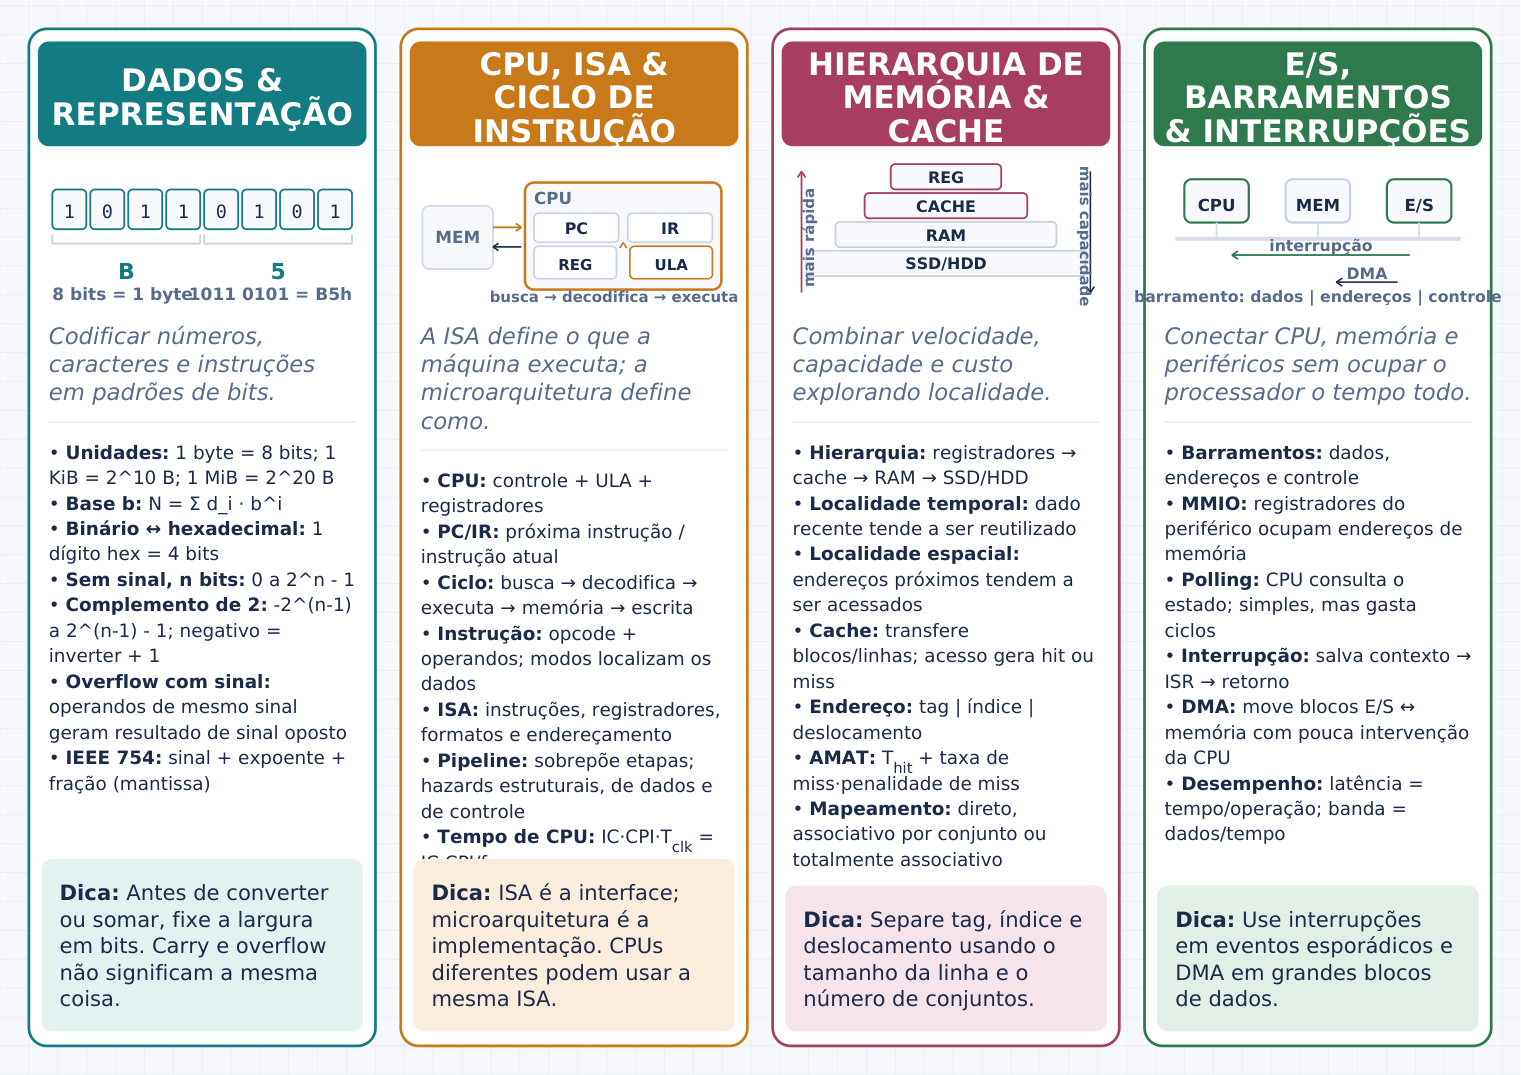

In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Arquitetura_Organizacao_Computadores.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFont(TTFont('DVMono', str(FONT_DIR / 'DejaVuSansMono.ttf')))
pdfmetrics.registerFontFamily(
    'DVCond',
    normal='DVCond',
    bold='DVCond-Bold',
    italic='DVCond-Oblique',
    boldItalic='DVCond-Bold',
)

# ---------- palette: identical to the previous OneNote sheets ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')
SOFT = HexColor('#C8D1DF')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'DADOS &amp;<br/>REPRESENTAÇÃO',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'dados',
        'idea': 'Codificar números, caracteres e instruções em padrões de bits.',
        'formulas': [
            '<b>Unidades:</b> 1 byte = 8 bits; 1 KiB = 2^10 B; 1 MiB = 2^20 B',
            '<b>Base b:</b> N = Σ d_i · b^i',
            '<b>Binário ↔ hexadecimal:</b> 1 dígito hex = 4 bits',
            '<b>Sem sinal, n bits:</b> 0 a 2^n - 1',
            '<b>Complemento de 2:</b> -2^(n-1) a 2^(n-1) - 1; negativo = inverter + 1',
            '<b>Overflow com sinal:</b> operandos de mesmo sinal geram resultado de sinal oposto',
            '<b>IEEE 754:</b> sinal + expoente + fração (mantissa)',
        ],
        'tip': 'Antes de converter ou somar, fixe a largura em bits. Carry e overflow não significam a mesma coisa.',
    },
    {
        'title': 'CPU, ISA &amp;<br/>CICLO DE INSTRUÇÃO',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'cpu',
        'idea': 'A ISA define o que a máquina executa; a microarquitetura define como.',
        'formulas': [
            '<b>CPU:</b> controle + ULA + registradores',
            '<b>PC/IR:</b> próxima instrução / instrução atual',
            '<b>Ciclo:</b> busca → decodifica → executa → memória → escrita',
            '<b>Instrução:</b> opcode + operandos; modos localizam os dados',
            '<b>ISA:</b> instruções, registradores, formatos e endereçamento',
            '<b>Pipeline:</b> sobrepõe etapas; hazards estruturais, de dados e de controle',
            '<b>Tempo de CPU:</b> IC·CPI·T<sub>clk</sub> = IC·CPI/f',
        ],
        'tip': 'ISA é a interface; microarquitetura é a implementação. CPUs diferentes podem usar a mesma ISA.',
    },
    {
        'title': 'HIERARQUIA DE<br/>MEMÓRIA &amp; CACHE',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'memoria',
        'idea': 'Combinar velocidade, capacidade e custo explorando localidade.',
        'formulas': [
            '<b>Hierarquia:</b> registradores → cache → RAM → SSD/HDD',
            '<b>Localidade temporal:</b> dado recente tende a ser reutilizado',
            '<b>Localidade espacial:</b> endereços próximos tendem a ser acessados',
            '<b>Cache:</b> transfere blocos/linhas; acesso gera hit ou miss',
            '<b>Endereço:</b> tag | índice | deslocamento',
            '<b>AMAT:</b> T<sub>hit</sub> + taxa de miss·penalidade de miss',
            '<b>Mapeamento:</b> direto, associativo por conjunto ou totalmente associativo',
        ],
        'tip': 'Separe tag, índice e deslocamento usando o tamanho da linha e o número de conjuntos.',
    },
    {
        'title': 'E/S, BARRAMENTOS<br/>&amp; INTERRUPÇÕES',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'io',
        'idea': 'Conectar CPU, memória e periféricos sem ocupar o processador o tempo todo.',
        'formulas': [
            '<b>Barramentos:</b> dados, endereços e controle',
            '<b>MMIO:</b> registradores do periférico ocupam endereços de memória',
            '<b>Polling:</b> CPU consulta o estado; simples, mas gasta ciclos',
            '<b>Interrupção:</b> salva contexto → ISR → retorno',
            '<b>DMA:</b> move blocos E/S ↔ memória com pouca intervenção da CPU',
            '<b>Desempenho:</b> latência = tempo/operação; banda = dados/tempo',
        ],
        'tip': 'Use interrupções em eventos esporádicos e DMA em grandes blocos de dados.',
    },
]

# ---------- layout: identical geometry to the previous sheet ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle(
    'card_title',
    fontName='DVCond-Bold',
    fontSize=17.2,
    leading=18.6,
    textColor=WHITE,
    alignment=1,
    spaceAfter=0,
)
STYLE_IDEA = ParagraphStyle(
    'idea',
    fontName='DVCond-Oblique',
    fontSize=12.6,
    leading=15.6,
    textColor=MUTED,
)
STYLE_TIP = ParagraphStyle(
    'tip',
    fontName='DVCond',
    fontSize=11.7,
    leading=14.7,
    textColor=INK,
)


def arrow(c, x1, y1, x2, y2, color, width=1.2, head=5):
    c.setStrokeColor(color)
    c.setFillColor(color)
    c.setLineWidth(width)
    c.line(x1, y1, x2, y2)
    ang = math.atan2(y2 - y1, x2 - x1)
    for delta in (2.55, -2.55):
        c.line(
            x2,
            y2,
            x2 + head * math.cos(ang + delta),
            y2 + head * math.sin(ang + delta),
        )


def diagram_dados(c, ox, oy, dw, dh, color):
    bits = '10110101'
    box_gap = 2.2
    box_w = (dw - 7 * box_gap - 4) / 8
    box_h = 22
    y = oy + dh * 0.54
    x = ox + 2

    for i, bit in enumerate(bits):
        c.setFillColor(HexColor('#F8FAFD'))
        c.setStrokeColor(color)
        c.setLineWidth(1.0)
        c.roundRect(x, y, box_w, box_h, 2.5, fill=1, stroke=1)
        c.setFillColor(INK)
        c.setFont('DVMono', 10.2)
        c.drawCentredString(x + box_w / 2, y + 6.1, bit)
        x += box_w + box_gap

    # Hex grouping and labels.
    group_w = 4 * box_w + 3 * box_gap
    y_hex = oy + dh * 0.18
    for i, value in enumerate(('B', '5')):
        gx = ox + 2 + i * (group_w + box_gap)
        c.setStrokeColor(SOFT)
        c.setLineWidth(1.0)
        c.line(gx, y - 3, gx, y - 8)
        c.line(gx + group_w, y - 3, gx + group_w, y - 8)
        c.line(gx, y - 8, gx + group_w, y - 8)
        c.setFillColor(color)
        c.setFont('DVCond-Bold', 12.2)
        c.drawCentredString(gx + group_w / 2, y_hex, value)

    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 9.4)
    c.drawString(ox + 2, oy + 2, '8 bits = 1 byte')
    c.drawRightString(ox + dw - 2, oy + 2, '1011 0101 = B5h')


def diagram_cpu(c, ox, oy, dw, dh, color):
    mem_w = dw * 0.23
    mem_x = ox + 1
    mem_y = oy + dh * 0.25
    mem_h = dh * 0.46

    c.setFillColor(HexColor('#F8FAFD'))
    c.setStrokeColor(AXIS)
    c.setLineWidth(1.1)
    c.roundRect(mem_x, mem_y, mem_w, mem_h, 4, fill=1, stroke=1)
    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 9.3)
    c.drawCentredString(mem_x + mem_w / 2, mem_y + mem_h / 2 - 3, 'MEM')

    cpu_x = ox + dw * 0.34
    cpu_y = oy + dh * 0.10
    cpu_w = dw * 0.64
    cpu_h = dh * 0.78
    c.setFillColor(HexColor('#F8FAFD'))
    c.setStrokeColor(color)
    c.setLineWidth(1.4)
    c.roundRect(cpu_x, cpu_y, cpu_w, cpu_h, 5, fill=1, stroke=1)

    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 9.2)
    c.drawString(cpu_x + 5, cpu_y + cpu_h - 12, 'CPU')

    pad = 5
    small_h = 16
    pc_w = (cpu_w - 3 * pad) / 2
    pc_y = cpu_y + cpu_h - small_h - 17
    for label, bx in (('PC', cpu_x + pad), ('IR', cpu_x + 2 * pad + pc_w)):
        c.setFillColor(WHITE)
        c.setStrokeColor(SOFT)
        c.setLineWidth(0.9)
        c.roundRect(bx, pc_y, pc_w, small_h, 2.5, fill=1, stroke=1)
        c.setFillColor(INK)
        c.setFont('DVCond-Bold', 8.8)
        c.drawCentredString(bx + pc_w / 2, pc_y + 4.4, label)

    reg_y = cpu_y + 6
    reg_w = cpu_w * 0.42
    reg_h = 18
    c.setFillColor(WHITE)
    c.setStrokeColor(SOFT)
    c.roundRect(cpu_x + pad, reg_y, reg_w, reg_h, 2.5, fill=1, stroke=1)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 8.3)
    c.drawCentredString(cpu_x + pad + reg_w / 2, reg_y + 5, 'REG')

    ula_x = cpu_x + cpu_w - pad - reg_w
    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.roundRect(ula_x, reg_y, reg_w, reg_h, 2.5, fill=1, stroke=1)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 8.3)
    c.drawCentredString(ula_x + reg_w / 2, reg_y + 5, 'ULA')

    arrow(c, mem_x + mem_w, mem_y + mem_h * 0.66, cpu_x - 2, mem_y + mem_h * 0.66, color, 1.0, 3.8)
    arrow(c, cpu_x - 2, mem_y + mem_h * 0.35, mem_x + mem_w, mem_y + mem_h * 0.35, INK, 0.9, 3.6)
    arrow(c, cpu_x + cpu_w * 0.50, pc_y - 1, cpu_x + cpu_w * 0.50, reg_y + reg_h + 2, color, 0.9, 3.5)

    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 8.8)
    c.setFont('DVCond-Bold', 8.3)
    c.drawCentredString(ox + dw * 0.63, oy + 1, 'busca → decodifica → executa')


def diagram_memoria(c, ox, oy, dw, dh, color):
    levels = [
        ('REG', 0.36),
        ('CACHE', 0.53),
        ('RAM', 0.72),
        ('SSD/HDD', 0.91),
    ]
    row_h = 14
    y_top = oy + dh * 0.83
    for i, (label, frac) in enumerate(levels):
        w = dw * frac
        x = ox + (dw - w) / 2
        y = y_top - i * (row_h + 2)
        c.setFillColor(HexColor('#F8FAFD'))
        c.setStrokeColor(color if i < 2 else SOFT)
        c.setLineWidth(1.0)
        c.roundRect(x, y, w, row_h, 2.5, fill=1, stroke=1)
        c.setFillColor(INK)
        c.setFont('DVCond-Bold', 8.8)
        c.drawCentredString(x + w / 2, y + 3.7, label)

    arrow(c, ox + 5, oy + 6, ox + 5, oy + dh - 3, color, 1.0, 4)
    arrow(c, ox + dw - 5, oy + dh - 3, ox + dw - 5, oy + 6, INK, 0.9, 4)
    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 8.3)
    c.saveState()
    c.translate(ox + 12, oy + dh * 0.48)
    c.rotate(90)
    c.drawCentredString(0, 0, 'mais rápida')
    c.restoreState()
    c.saveState()
    c.translate(ox + dw - 11, oy + dh * 0.49)
    c.rotate(-90)
    c.drawCentredString(0, 0, 'mais capacidade')
    c.restoreState()


def diagram_io(c, ox, oy, dw, dh, color):
    bus_y = oy + dh * 0.47
    c.setStrokeColor(AXIS)
    c.setLineWidth(2.2)
    c.line(ox + 6, bus_y, ox + dw - 6, bus_y)

    nodes = [
        ('CPU', ox + dw * 0.17),
        ('MEM', ox + dw * 0.50),
        ('E/S', ox + dw * 0.83),
    ]
    box_w = dw * 0.21
    box_h = 24
    for label, cx in nodes:
        bx = cx - box_w / 2
        by = bus_y + 9
        c.setFillColor(HexColor('#F8FAFD'))
        c.setStrokeColor(color if label != 'MEM' else SOFT)
        c.setLineWidth(1.2)
        c.roundRect(bx, by, box_w, box_h, 4, fill=1, stroke=1)
        c.setFillColor(INK)
        c.setFont('DVCond-Bold', 9.2)
        c.drawCentredString(cx, by + 6.3, label)
        c.setStrokeColor(AXIS)
        c.setLineWidth(1.0)
        c.line(cx, bus_y, cx, by)

    # Interrupt: I/O -> CPU. DMA: I/O -> memory.
    arrow(c, ox + dw * 0.80, bus_y - 9, ox + dw * 0.22, bus_y - 9, color, 1.0, 4)
    arrow(c, ox + dw * 0.76, bus_y - 24, ox + dw * 0.56, bus_y - 24, INK, 0.9, 4)
    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 8.7)
    c.drawCentredString(ox + dw * 0.51, bus_y - 7, 'interrupção')
    c.drawCentredString(ox + dw * 0.66, bus_y - 22, 'DMA')
    c.drawCentredString(ox + dw * 0.50, oy + 1, 'barramento: dados | endereços | controle')


DIAGRAMS = {
    'dados': diagram_dados,
    'cpu': diagram_cpu,
    'memoria': diagram_memoria,
    'io': diagram_io,
}


def draw_card(c, card, cx):
    color, tint = card['color'], card['tint']

    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(cx, CARD_BOTTOM, CARD_W, CARD_H, 10, fill=1, stroke=1)

    # Header.
    header_h = 58
    header_y = CARD_TOP - 7 - header_h
    c.setFillColor(color)
    c.roundRect(cx + 5, header_y, CARD_W - 10, header_h, 6, fill=1, stroke=0)
    title = Paragraph(card['title'], STYLE_TITLE)
    _, title_h = title.wrapOn(c, CARD_W - 22, header_h - 6)
    title.drawOn(c, cx + 11, header_y + (header_h - title_h) / 2)

    cursor = header_y - 11

    # Diagram.
    diagram_h = 76
    diagram_y = cursor - diagram_h
    DIAGRAMS[card['kind']](c, cx + 11, diagram_y, CARD_W - 22, diagram_h, color)
    cursor = diagram_y - 10

    # Key idea.
    idea = Paragraph(card['idea'], STYLE_IDEA)
    _, idea_h = idea.wrapOn(c, CARD_W - 22, 70)
    idea.drawOn(c, cx + 11, cursor - idea_h)
    cursor -= idea_h + 9

    c.setStrokeColor(LINE)
    c.setLineWidth(0.8)
    c.line(cx + 11, cursor, cx + CARD_W - 11, cursor)
    cursor -= 10

    # Tip anchored at the bottom.
    tip_y = CARD_BOTTOM + 8
    tip = Paragraph('<b>Dica:</b> ' + card['tip'], STYLE_TIP)
    _, tip_text_h = tip.wrapOn(c, CARD_W - 34, 130)
    tip_h = max(72, tip_text_h + 22)
    tip_top = tip_y + tip_h

    # Auto-size body to fit, preserving the established legibility.
    formula_html = '<br/>'.join('• ' + item for item in card['formulas'])
    available_h = cursor - tip_top - 20
    font_size = 12.3
    leading = 16.2
    while True:
        style_formula = ParagraphStyle(
            'formula_' + card['kind'],
            fontName='DVCond',
            fontSize=font_size,
            leading=leading,
            textColor=INK,
        )
        formulas = Paragraph(formula_html, style_formula)
        _, formula_h = formulas.wrapOn(c, CARD_W - 22, 430)
        if formula_h <= available_h or font_size <= 10.20:
            break
        font_size -= 0.15
        leading -= 0.15

    formulas.drawOn(c, cx + 11, cursor - formula_h)

    c.setFillColor(tint)
    c.roundRect(cx + 7, tip_y, CARD_W - 14, tip_h, 6, fill=1, stroke=0)
    tip.drawOn(c, cx + 17, tip_y + (tip_h - tip_text_h) / 2)


c = canvas.Canvas(str(OUT), pagesize=landscape(A4))
c.setTitle('Arquitetura e Organização de Computadores - Cheat Sheet OneNote')
c.setAuthor('')

# Background grid.
c.setFillColor(BG)
c.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
c.setStrokeColor(GRID)
c.setLineWidth(0.35)
step = 16
x = 0
while x < PAGE_W:
    c.line(x, 0, x, PAGE_H)
    x += step
y = 0
while y < PAGE_H:
    c.line(0, y, PAGE_W, y)
    y += step

x = MARGIN
for card in CARDS:
    draw_card(c, card, x)
    x += CARD_W + GAP

c.save()
print(f'PDF gerado em {OUT}')


# ===== renderização do PDF gerado =====
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Arquitetura_Organizacao_Computadores.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF acima).

### 🟢 DADOS & REPRESENTAÇÃO

**Ideia:** Codificar números, caracteres e instruções em padrões de bits.

- Unidades: 1 byte = 8 bits; 1 KiB = 2^10 B; 1 MiB = 2^20 B
- Base b: N = Σ d_i · b^i
- Binário ↔ hexadecimal: 1 dígito hex = 4 bits
- Sem sinal, n bits: 0 a 2^n - 1
- Complemento de 2: -2^(n-1) a 2^(n-1) - 1; negativo = inverter + 1
- Overflow com sinal: operandos de mesmo sinal geram resultado de sinal oposto
- IEEE 754: sinal + expoente + fração (mantissa)

> 💡 **Dica:** Antes de converter ou somar, fixe a largura em bits. Carry e overflow não significam a mesma coisa.

### 🟢 CPU, ISA & CICLO DE INSTRUÇÃO

**Ideia:** A ISA define o que a máquina executa; a microarquitetura define como.

- CPU: controle + ULA + registradores
- PC/IR: próxima instrução / instrução atual
- Ciclo: busca → decodifica → executa → memória → escrita
- Instrução: opcode + operandos; modos localizam os dados
- ISA: instruções, registradores, formatos e endereçamento
- Pipeline: sobrepõe etapas; hazards estruturais, de dados e de controle
- Tempo de CPU: IC·CPI·T_clk = IC·CPI/f

> 💡 **Dica:** ISA é a interface; microarquitetura é a implementação. CPUs diferentes podem usar a mesma ISA.

### 🟢 HIERARQUIA DE MEMÓRIA & CACHE

**Ideia:** Combinar velocidade, capacidade e custo explorando localidade.

- Hierarquia: registradores → cache → RAM → SSD/HDD
- Localidade temporal: dado recente tende a ser reutilizado
- Localidade espacial: endereços próximos tendem a ser acessados
- Cache: transfere blocos/linhas; acesso gera hit ou miss
- Endereço: tag | índice | deslocamento
- AMAT: T_hit + taxa de miss·penalidade de miss
- Mapeamento: direto, associativo por conjunto ou totalmente associativo

> 💡 **Dica:** Separe tag, índice e deslocamento usando o tamanho da linha e o número de conjuntos.

### 🟢 E/S, BARRAMENTOS & INTERRUPÇÕES

**Ideia:** Conectar CPU, memória e periféricos sem ocupar o processador o tempo todo.

- Barramentos: dados, endereços e controle
- MMIO: registradores do periférico ocupam endereços de memória
- Polling: CPU consulta o estado; simples, mas gasta ciclos
- Interrupção: salva contexto → ISR → retorno
- DMA: move blocos E/S ↔ memória com pouca intervenção da CPU
- Desempenho: latência = tempo/operação; banda = dados/tempo

> 💡 **Dica:** Use interrupções em eventos esporádicos e DMA em grandes blocos de dados.


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


In [2]:

import struct

print("=" * 60)
print("1) BASES: converter 173 decimal")
n = 173
print(f"   173 = 0b{bin(n)[2:]} (binario) = 0x{hex(n)[2:].upper()} (hex)")
print(f"   hex -> 4 bits por digito: 0xAD = 1010 1101")

print("\n2) COMPLEMENTO DE 2 (8 bits): representar -42")
x = 42
c2 = (1 << 8) - x
print(f"   42  = 0b{bin(x)[2:]:>08s}")
print(f"   -42 = 0b{bin(c2)[2:]:>08s}  (= 11111111 - 42 + 1)")

print("\n3) SOMAR COM OVERFLOW (8 bits): 100 + 60")
soma = 100 + 60
print(f"   100 + 60 = {soma} -> em 8 bits: {soma & 0xFF} (overflow! carry descartado)")

print("\n4) IEEE 754 (float 32 bits): representacao de -6.5")
b = struct.pack(">f", -6.5)
bits = "".join(f"{byte:08b}" for byte in b)
print(f"   bits: {bits}")
print(f"   sinal={bits[0]} | expoente={int(bits[1:9],2)} (bias 127) | mantissa={bits[9:]}")

print("\n5) TEMPO DE CPU: IC = 2e9, CPI = 1.5, f = 3 GHz")
IC, CPI, f = 2e9, 1.5, 3e9
t_cpu = IC*CPI/f
print(f"   Tempo = {t_cpu:.3f} s")

print("\n6) CACHE - AMAT com taxa de miss de 5%")
t_hit, miss, t_miss = 1e-9, 0.05, 100e-9
amat = t_hit + miss*t_miss
print(f"   AMAT = {amat*1e9:.1f} ns")

print("\n7) PIPELINE: 5 estagios, 100 instrucoes, clock 2 GHz")
n_ins, estagios = 100, 5
t_sem = n_ins*estagios/(2e9)
t_com = (n_ins + estagios - 1)/(2e9)
print(f"   sem pipeline = {t_sem*1e9:.0f} ns | com pipeline = {t_com*1e9:.0f} ns "
      f"| speedup = {t_sem/t_com:.1f}x")
print("\nOK - numeros, IEEE754 e desempenho simulados em Python.")


1) BASES: converter 173 decimal
   173 = 0b10101101 (binario) = 0xAD (hex)
   hex -> 4 bits por digito: 0xAD = 1010 1101

2) COMPLEMENTO DE 2 (8 bits): representar -42
   42  = 0b00101010
   -42 = 0b11010110  (= 11111111 - 42 + 1)

3) SOMAR COM OVERFLOW (8 bits): 100 + 60
   100 + 60 = 160 -> em 8 bits: 160 (overflow! carry descartado)

4) IEEE 754 (float 32 bits): representacao de -6.5
   bits: 11000000110100000000000000000000
   sinal=1 | expoente=129 (bias 127) | mantissa=10100000000000000000000

5) TEMPO DE CPU: IC = 2e9, CPI = 1.5, f = 3 GHz
   Tempo = 1.000 s

6) CACHE - AMAT com taxa de miss de 5%
   AMAT = 6.0 ns

7) PIPELINE: 5 estagios, 100 instrucoes, clock 2 GHz
   sem pipeline = 250 ns | com pipeline = 52 ns | speedup = 4.8x

OK - numeros, IEEE754 e desempenho simulados em Python.


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
